# Extract Demand Days
##### Purpose: This notebook will extract days that are both hot (tasmax) and high demand
##### Version history: 01/07/2025 Alex Dunne, created, edited from Doug Richardson Hot & Cloudy initial work

In [1]:
import xarray as xr
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
from xhistogram.xarray import histogram

### Read in Demand Data

In [2]:
#Read in CSV file and read first column as index column in date time format
demand = pd.read_csv(
    "/home/565/ad1803/Hot_Cloudy/Demand/input_data/hourly_demand_20090701-20231230.csv",
    index_col=0,
    parse_dates=True
)

demand.index = pd.to_datetime(demand.index)

In [3]:
# Calculate total demand of NEM region
demand["NEM"] = demand.sum(axis=1)

In [4]:
#Create xarray dataset
demand = xr.DataArray(
    demand.transpose(),
    dims=["region", "time"],
    coords={"region": demand.columns, "time": demand.index.values}
)

In [5]:
#Converts from UTC to Aus Eastern Standrd time for later analysis 
demand["time"] = demand["time"] + np.timedelta64(10, 'h')

#Same time slicing same as BARRA
demand = demand.sel(time=slice("2009-07-01", "2023-12-30"))

### Read in BARRA Data

In [6]:
tasmax = xr.open_mfdataset(
    "/home/565/ad1803/Hot_Cloudy/Demand/output_data/barra/*.nc",
)

In [7]:
#Himawari data starts in August 2015
tasmax = tasmax.sel(time=slice("2015-08-01", "2023-12-30"))
tasmax = tasmax.tasmax.compute()

In [8]:
#Aliging tasmax time into date64[ns]
tasmax = tasmax.assign_coords(
    time=pd.date_range("2015-08-01T00:00", periods=tasmax.sizes['time'], freq="h")
)

common_times = np.intersect1d(tasmax['time'], demand['time'])

tasmax_aligned = tasmax.sel(time=common_times)
demand_aligned = demand.sel(time=common_times)

#Aligniing both times
common_times = np.intersect1d(tasmax['time'], demand['time'])

tasmax = tasmax_aligned.sel(time=common_times)
demand = demand_aligned.sel(time=common_times)

In [9]:
tasmax["time"] = demand["time"]

In [10]:
#convert K to C
tasmax = tasmax - 273.15

In [11]:
#Re-order demand region dimension to match tasmax
demand = demand.sel(region=tasmax.region.values)

### Cut to Warm or Cold Season (summer +/- month)

In [12]:
# --- For demand ---
demand_month = demand["time.month"]
demand_summer_mask = (demand_month == 5) |(demand_month == 6)|(demand_month == 7)|(demand_month == 8)|(demand_month == 9)
demand = demand.sel(time=demand["time"][demand_summer_mask])

# --- For tasmax ---
tasmax_month = tasmax["time.month"]
tasmax_summer_mask = (demand_month == 5) |(demand_month == 6)|(demand_month == 7)|(demand_month == 8)|(demand_month == 9)
tasmax = tasmax.sel(time=tasmax["time"][tasmax_summer_mask])

### Pre and Post Solar Year Mask

In [ ]:
# Pre Solar 2010, 2011, 2013 Post Solar 2021, 2022, 2023
# --- For demand ---
year = demand["time.year"]

pre_mask = (year == 2010) | (year == 2011) | (year == 2012) | (year == 2013)
pre_demand = demand.sel(time=demand["time"][pre_mask])

post_mask = (year == 2021) | (year == 2022) | (year == 2023)
post_demand = demand.sel(time=demand["time"][post_mask])


# --- For tasmax ---
year = tasmax["time.year"]

pre_mask = (year == 2010) | (year == 2011) | (year == 2012) | (year == 2013)
pre_tasmax = tasmax.sel(time=tasmax["time"][pre_mask])

post_mask = (year == 2021) | (year == 2022) | (year == 2023)
post_tasmax = tasmax.sel(time=tasmax["time"][post_mask])


### Demand vs Temp Break

In [13]:
#Daily maximums 
demand_dmax = demand.resample(time="1D").max()
tasmax_dmax = tasmax.resample(time="1D").max()

In [14]:
def day_of_week_num(dts):
    """
    dts: array of datetime64
    
    From https://stackoverflow.com/a/54264187
    """
    # Monday is day 0
    return (dts.astype('datetime64[D]').view('int64') - 4) % 7

In [15]:
tasmax_dmax = tasmax_dmax.assign_coords(dayofweek=("time", day_of_week_num(tasmax_dmax.time.values)))
demand_dmax = demand_dmax.assign_coords(dayofweek=("time", day_of_week_num(demand_dmax.time.values)))

In [16]:
def plot_scatter(xds, yds, add_weekend=True):
    """
    Scatter xds against yds
    
    xds, yds: datasets to plot
    add_weekend: also plot weekend
    """
    fig, ax = plt.subplots(2, 3, figsize=(7, 4))
    
    for i, r in enumerate(xds.region.values):
        xd = xds.where(xds.dayofweek < 5).dropna("time").sel(region=r)
        yd = yds.where(yds.dayofweek < 5).dropna("time").sel(region=r)
        
        ax.flatten()[i].scatter(xd, yd, color="tab:blue", alpha=0.5, s=5, label="Weekday")
        
        if add_weekend:
            xd_wknd = xds.where(xds.dayofweek >= 5).dropna("time").sel(region=r)
            yd_wknd = yds.where(yds.dayofweek >= 5).dropna("time").sel(region=r)
            
            ax.flatten()[i].scatter(xd_wknd, yd_wknd, color="tab:orange", alpha=0.5, s=5, label="Weekend")
        
        ax.flatten()[i].set_title(r)
        ax.flatten()[i].tick_params(axis='x', labelrotation=40)
        
        if r == "TAS":
            xq = xd.quantile(0.05, "time")
            ax.flatten()[i].axvline(xq, c="k")
        else:
            xq = xd.quantile(0.05, "time")
            ax.flatten()[i].axvline(xq, c="k")
        
        yq = yd.quantile(0.95, "time")
        ax.flatten()[i].axhline(yq, c="k")
        
        if i > 2:
            ax.flatten()[i].set_xlabel("Daily min T [deg C]")
        if i in [0, 3]:
            ax.flatten()[i].set_ylabel("Daily max\ndemand [MWh]")
        
    plt.tight_layout()

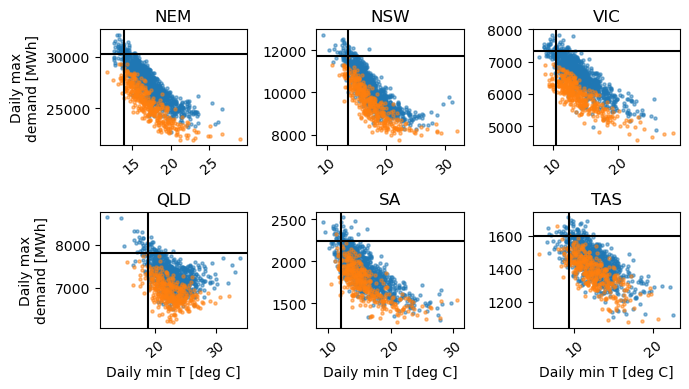

In [17]:
plot_scatter(tasmax_dmax, demand_dmax)

### Write Dataset - Cold and High Demand

In [18]:
# Resample to daily maximums
demand_dmax = demand.resample(time="1D").max()
tasmax_dmax = tasmax.resample(time="1D").max()

# Loop through each region
regions = demand.region.values
filtered_data = {}

for region in regions:
    # Extract region-specific data
    state_demand = demand_dmax.sel(region=region)
    state_tmax = tasmax_dmax.sel(region=region)
    
    # Calculate 95th percentiles
    t05 = state_tmax.quantile(0.05, dim='time') #For winter, set to 5th percentile temp
    d95 = state_demand.quantile(0.95, dim='time')
    
    # Create mask for concurrent high tasmax and demand
    mask = (state_tmax > t05) & (state_demand > d95)
    
    # Apply mask
    tmax_filtered = state_tmax.where(mask, drop=True)
    demand_filtered = state_demand.where(mask, drop=True)
    
    # Store in dictionary
    filtered_data[region] = xr.Dataset({
        'tasmax': tmax_filtered,
        'demand': demand_filtered
    })

# Combine all regions into a single Dataset
combined_ds = xr.concat(
    [filtered_data[region].expand_dims(region=[region]) for region in regions],
    dim='region'
)

# Save as NetCDF
#combined_ds.to_netcdf("/home/565/ad1803/Hot_Cloudy/Demand/output_data/demand_days/wint_warm_high_demand_days.nc")

### Debug Section

In [30]:
# Loop through each region
regions = demand.region.values
filtered_data = {}

for region in regions:
    # Extract region-specific data
    state_demand = demand.sel(region=region)
    state_tmax = tasmax.sel(region=region)
    
    # Resample to daily maximums for this region
    state_demand_dmax = state_demand.resample(time="1D").max()
    state_tmax_dmax = state_tmax.resample(time="1D").max()
    
    # Calculate percentiles for this region
    t05 = state_tmax_dmax.quantile(0.05, dim='time')
    d95 = state_demand_dmax.quantile(0.95, dim='time')
    
    # Create mask for concurrent high tasmax and demand
    mask = (state_tmax_dmax > t05) & (state_demand_dmax > d95)
    
    # Apply mask
    tmax_filtered = state_tmax_dmax.where(mask, drop=True)
    demand_filtered = state_demand_dmax.where(mask, drop=True)
    
    # Store in dictionary
    filtered_data[region] = xr.Dataset({
        'tasmax': tmax_filtered,
        'demand': demand_filtered
    })

# Combine all regions into a single Dataset
combined_ds = xr.concat(
    [filtered_data[region].expand_dims(region=[region]) for region in regions],
    dim='region'
)

In [36]:
for region in regions:
    state_demand = demand.sel(region=region)
    state_tmax = tasmax.sel(region=region)
    state_demand_dmax = state_demand.resample(time="1D").max()
    state_tmax_dmax = state_tmax.resample(time="1D").max()

    t05 = state_tmax_dmax.quantile(0.05, dim='time')
    d95 = state_demand_dmax.quantile(0.95, dim='time')

    mask = (state_tmax_dmax > t05) & (state_demand_dmax > d95)
    print(f"{region}: {mask.sum().values} days above threshold")

NEM: 32 days above threshold
NSW: 31 days above threshold
VIC: 38 days above threshold
QLD: 36 days above threshold
SA: 42 days above threshold
TAS: 49 days above threshold
